# Estudo da Similaridade entre ataques do CICDDoS2019 01/12


## Verificação das semelhanças

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


# Caminho informado diretamente.
CSV_PATH = Path("C:\\GitHub\\anomaly-detection-data-stream\\data\\BALANCED.csv")

# Nome normalizado da coluna de rótulo.
LABEL_COLUMN = "Label"

if not CSV_PATH.is_file():
    raise FileNotFoundError(
        f"Dataset não encontrado em: {CSV_PATH.resolve()}"
    )

# utf-8-sig também remove um possível BOM do início do cabeçalho.
rawData = pd.read_csv(
    CSV_PATH,
    encoding="utf-8-sig",
    low_memory=False,
    skipinitialspace=True,
)

# Guarda os nomes originais para mostrar as correções.
originalColumns = list(rawData.columns)

# Remove espaços no início e no final dos nomes.
normalizedColumns = [
    str(column).strip()
    for column in rawData.columns
]

# Verifica se a limpeza criou nomes duplicados.
duplicatedColumnNames = (
    pd.Series(normalizedColumns)[
        pd.Series(normalizedColumns).duplicated(
            keep=False
        )
    ]
    .unique()
    .tolist()
)

if duplicatedColumnNames:
    raise ValueError(
        "A normalização gerou colunas duplicadas: "
        f"{duplicatedColumnNames}"
    )

rawData.columns = normalizedColumns

# Registra as correções feitas nos nomes.
renamedColumns = {
    original: normalized
    for original, normalized in zip(
        originalColumns,
        normalizedColumns,
    )
    if original != normalized
}

if LABEL_COLUMN not in rawData.columns:
    raise KeyError(
        f"A coluna '{LABEL_COLUMN}' não foi encontrada. "
        f"Colunas disponíveis: {rawData.columns.tolist()}"
    )

# Remove linhas sem rótulo.
rawData = rawData.dropna(
    subset=[LABEL_COLUMN]
).copy()

# Remove espaços dos valores dos rótulos.
rawData[LABEL_COLUMN] = (
    rawData[LABEL_COLUMN]
    .astype(str)
    .str.strip()
)

# Remove rótulos vazios.
rawData = rawData[
    rawData[LABEL_COLUMN].ne("")
].copy()

# Remove índices salvos acidentalmente no CSV.
indexColumns = [
    column
    for column in rawData.columns
    if column.lower().startswith("unnamed")
]

candidateColumns = [
    column
    for column in rawData.columns
    if column not in indexColumns + [LABEL_COLUMN]
]

numericData = {}
categoricalColumns = []
invalidNumericCounts = {}

# Testa o conteúdo completo de cada coluna.
for column in candidateColumns:
    convertedValues = pd.to_numeric(
        rawData[column],
        errors="coerce",
    )

    # Identifica textos presentes em uma possível coluna numérica.
    invalidMask = (
        rawData[column].notna()
        & convertedValues.isna()
    )

    invalidCount = int(
        invalidMask.sum()
    )

    # Qualquer coluna com texto é tratada como categórica.
    if invalidCount > 0:
        categoricalColumns.append(column)
        invalidNumericCounts[column] = invalidCount
        continue

    numericData[column] = convertedValues

# Constrói o dataset somente com features numéricas.
preparedData = pd.DataFrame(
    numericData,
    index=rawData.index,
)

# Converte valores infinitos em ausentes.
preparedData = preparedData.replace(
    [np.inf, -np.inf],
    np.nan,
)

preparedData[LABEL_COLUMN] = (
    rawData[LABEL_COLUMN]
)

# Remove features numéricas sem variação.
constantColumns = [
    column
    for column in preparedData.columns
    if column != LABEL_COLUMN
    and preparedData[column].nunique(
        dropna=True
    ) <= 1
]

preparedData = preparedData.drop(
    columns=constantColumns
)

featureColumns = [
    column
    for column in preparedData.columns
    if column != LABEL_COLUMN
]

# Cria uma assinatura baseada somente nas features.
preparedData["_featureHash"] = (
    pd.util.hash_pandas_object(
        preparedData[featureColumns],
        index=False,
    )
)

# Detecta vetores iguais ligados a classes diferentes.
labelsPerFeatureVector = (
    preparedData
    .groupby("_featureHash")[LABEL_COLUMN]
    .transform("nunique")
)

ambiguousMask = (
    labelsPerFeatureVector > 1
)

ambiguousRows = int(
    ambiguousMask.sum()
)

# Remove observações com features idênticas e rótulos conflitantes.
preparedData = preparedData.loc[
    ~ambiguousMask
].copy()

duplicateRows = int(
    preparedData.duplicated(
        subset=featureColumns + [LABEL_COLUMN]
    ).sum()
)

# Impede que cópias idênticas sejam divididas entre treino e teste.
preparedData = preparedData.drop_duplicates(
    subset=featureColumns + [LABEL_COLUMN]
)

cleanData = (
    preparedData
    .drop(columns="_featureHash")
    .reset_index(drop=True)
)

featureColumns = [
    column
    for column in cleanData.columns
    if column != LABEL_COLUMN
]

missingSummary = (
    cleanData[featureColumns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

classCounts = (
    cleanData[LABEL_COLUMN]
    .value_counts()
    .rename_axis("classe")
    .reset_index(name="amostras")
)

print("Arquivo:", CSV_PATH.resolve())
print("Formato original:", rawData.shape)
print("Formato tratado:", cleanData.shape)
print("Features numéricas utilizadas:", len(featureColumns))
print("Colunas categóricas removidas:", categoricalColumns)
print("Colunas de índice removidas:", indexColumns)
print("Features constantes removidas:", constantColumns)
print("Linhas ambíguas removidas:", ambiguousRows)
print("Duplicatas removidas:", duplicateRows)

print("\nCabeçalhos corrigidos:")
display(
    pd.DataFrame(
        renamedColumns.items(),
        columns=[
            "nomeOriginal",
            "nomeCorrigido",
        ],
    )
)

print("\nColunas removidas por conterem texto:")
display(
    pd.DataFrame(
        {
            "coluna": list(
                invalidNumericCounts.keys()
            ),
            "valoresNaoNumericos": list(
                invalidNumericCounts.values()
            ),
        }
    )
)

print("\nDistribuição final das classes:")
display(classCounts)

print("\nValores ausentes por feature:")
display(
    missingSummary[
        missingSummary.gt(0)
    ].rename("valoresAusentes")
)

Arquivo: C:\GitHub\anomaly-detection-data-stream\data\BALANCED.CSV
Formato original: (120000, 88)
Formato tratado: (119695, 70)
Features numéricas utilizadas: 69
Colunas categóricas removidas: ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'SimillarHTTP']
Colunas de índice removidas: ['Unnamed: 0']
Features constantes removidas: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Count', 'PSH Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Linhas ambíguas removidas: 18
Duplicatas removidas: 287

Cabeçalhos corrigidos:


,nomeOriginal,nomeCorrigido



Colunas removidas por conterem texto:


,coluna,valoresNaoNumericos
0,Flow ID,120000
1,Source IP,120000
2,Destination IP,120000
3,Timestamp,120000
4,SimillarHTTP,394



Distribuição final das classes:


,classe,amostras
0,DrDoS_DNS,10000
1,Syn,10000
2,DrDoS_SSDP,10000
3,DrDoS_NTP,10000
4,DrDoS_UDP,10000
5,TFTP,9999
6,UDP-lag,9999
7,DrDoS_LDAP,9998
8,DrDoS_MSSQL,9998
9,DrDoS_SNMP,9994



Valores ausentes por feature:


Flow Packets/s    3721
Flow Bytes/s      3721
Name: valoresAusentes, dtype: int64

Resultados do One-vs-All:


,precision,recall,f1-score,support,auc
BENIGN,0.9952,0.9997,0.9974,2914,1.0000
DrDoS_DNS,0.8189,0.7973,0.8080,3000,0.9886
DrDoS_LDAP,0.6911,0.7950,0.7394,3000,0.9831
DrDoS_MSSQL,0.8152,0.6826,0.7430,2999,0.9748
DrDoS_NTP,0.9760,0.9913,0.9836,3000,0.9999
DrDoS_NetBIOS,0.7772,0.7355,0.7558,2998,0.9828
DrDoS_SNMP,0.8407,0.8939,0.8665,2998,0.9953
DrDoS_SSDP,0.6232,0.6617,0.6419,3000,0.9642
DrDoS_UDP,0.6444,0.6807,0.6620,3000,0.9728
Syn,0.6898,0.6183,0.6521,3000,0.9783


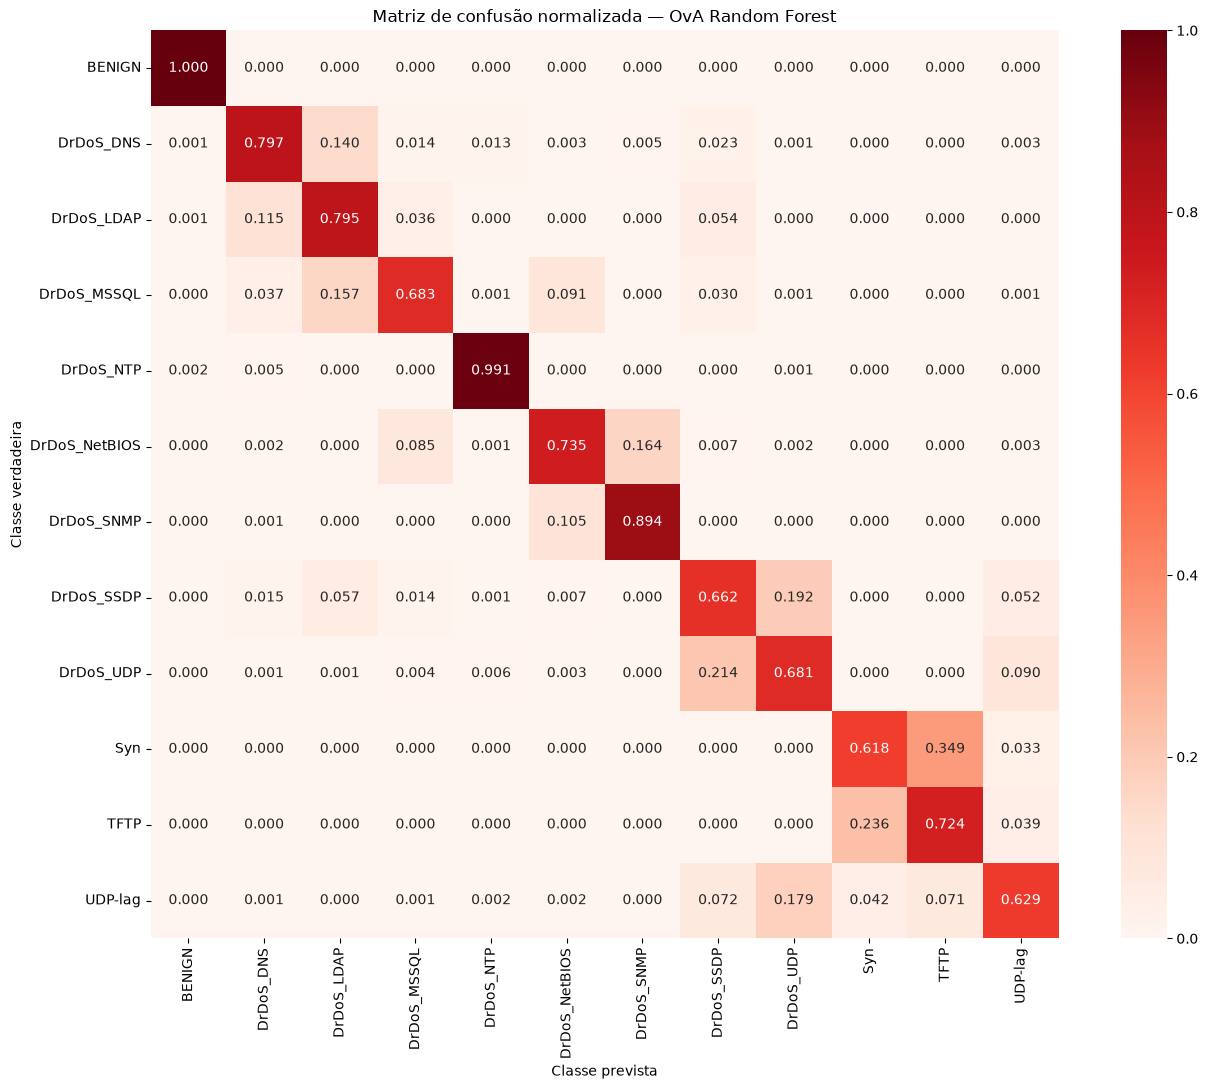

Média das confusões positivas: 3.9800%
Desvio-padrão das confusões positivas: 6.6301%
Limiar final (média + desvio-padrão): 10.6101%

Ataques mais confundidos:


,posicao,ataqueA,ataqueB,errosAparaB,errosBparaA,errosTotais,confusaoAparaBPercentual,confusaoBparaAPercentual,confusaoSimetricaPercentual,mesmoGrupoPeloLimiar
0,1,Syn,TFTP,1047,708,1755,34.9000%,23.6000%,29.2500%,True
1,2,DrDoS_SSDP,DrDoS_UDP,576,643,1219,19.2000%,21.4333%,20.3167%,True
2,3,DrDoS_UDP,UDP-lag,270,538,808,9.0000%,17.9333%,13.4667%,True
3,4,DrDoS_NetBIOS,DrDoS_SNMP,491,314,805,16.3776%,10.4736%,13.4256%,True
4,5,DrDoS_DNS,DrDoS_LDAP,420,344,764,14.0000%,11.4667%,12.7333%,True
5,6,DrDoS_LDAP,DrDoS_MSSQL,107,471,578,3.5667%,15.7052%,9.6360%,False
6,7,DrDoS_MSSQL,DrDoS_NetBIOS,273,256,529,9.1030%,8.5390%,8.8210%,False
7,8,DrDoS_SSDP,UDP-lag,157,217,374,5.2333%,7.2333%,6.2333%,False
8,9,DrDoS_LDAP,DrDoS_SSDP,161,171,332,5.3667%,5.7000%,5.5333%,False
9,10,TFTP,UDP-lag,118,212,330,3.9333%,7.0667%,5.5000%,False



Grupos finais de ataques semelhantes:


,grupo,quantidadeAtaques,ataques
0,1,2,"DrDoS_SSDP, DrDoS_UDP"
1,2,1,UDP-lag
2,3,1,DrDoS_NTP
3,4,2,"Syn, TFTP"
4,5,2,"DrDoS_NetBIOS, DrDoS_SNMP"
5,6,2,"DrDoS_DNS, DrDoS_LDAP"
6,7,1,DrDoS_MSSQL


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations
from IPython.display import display
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import squareform
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize


RANDOM_STATE = 42
TEST_SIZE = 0.30

# Classes que não participam do agrupamento de ataques.
NON_ATTACK_LABELS = {
    "BENIGN",
    "NORMAL",
}


# Prepara as features e os rótulos.
X = cleanData[
    featureColumns
].copy()

y = cleanData[
    LABEL_COLUMN
].copy()


# Divide os dados antes da imputação.
XTrain, XTest, yTrain, yTest = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)


# A imputação é ajustada somente com o treinamento.
basePipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
            ),
        ),
        (
            "randomForest",
            RandomForestClassifier(
                n_estimators=200,
                min_samples_leaf=2,
                max_features="sqrt",
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)


# Treina um Random Forest para cada classe contra as demais.
ovaModel = OneVsRestClassifier(
    basePipeline,
    n_jobs=1,
)

ovaModel.fit(
    XTrain,
    yTrain,
)


# Realiza as predições no conjunto de teste.
yPredicted = ovaModel.predict(
    XTest
)

testProbabilities = ovaModel.predict_proba(
    XTest
)

modelClasses = list(
    ovaModel.classes_
)


# Calcula precisão, recall e F1-score.
report = classification_report(
    yTest,
    yPredicted,
    labels=modelClasses,
    output_dict=True,
    zero_division=0,
)

classificationTable = (
    pd.DataFrame(report)
    .T
    .loc[
        modelClasses,
        [
            "precision",
            "recall",
            "f1-score",
            "support",
        ],
    ]
)

classificationTable["support"] = (
    classificationTable["support"]
    .astype(int)
)


# Calcula a AUC de cada classe contra todas as demais.
yTestBinary = label_binarize(
    yTest,
    classes=modelClasses,
)

aucValues = []

for classIndex in range(
    len(modelClasses)
):
    binaryTarget = (
        yTestBinary[:, classIndex]
    )

    classProbabilities = (
        testProbabilities[:, classIndex]
    )

    aucValues.append(
        roc_auc_score(
            binaryTarget,
            classProbabilities,
        )
    )

classificationTable[
    "auc"
] = aucValues


print("Resultados do One-vs-All:")

display(
    classificationTable.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "auc": "{:.4f}",
    })
)


# Calcula a matriz de confusão absoluta.
confusionCounts = confusion_matrix(
    yTest,
    yPredicted,
    labels=modelClasses,
)

confusionCountsFrame = pd.DataFrame(
    confusionCounts,
    index=modelClasses,
    columns=modelClasses,
)


# Normaliza cada linha pela quantidade real da classe.
confusionNormalized = confusion_matrix(
    yTest,
    yPredicted,
    labels=modelClasses,
    normalize="true",
)

confusionFrame = pd.DataFrame(
    confusionNormalized,
    index=modelClasses,
    columns=modelClasses,
)


# Exibe a matriz de confusão normalizada.
plt.figure(figsize=(14, 11))

sns.heatmap(
    confusionFrame,
    cmap="Reds",
    annot=True,
    fmt=".3f",
    square=True,
    vmin=0,
    vmax=1,
)

plt.title(
    "Matriz de confusão normalizada — OvA Random Forest"
)

plt.xlabel("Classe prevista")
plt.ylabel("Classe verdadeira")
plt.tight_layout()
plt.show()


# Seleciona somente as classes de ataque.
attackClasses = [
    className
    for className in modelClasses
    if str(className).strip().upper()
    not in NON_ATTACK_LABELS
]

if len(attackClasses) < 2:
    raise ValueError(
        "São necessárias pelo menos duas classes de ataque."
    )


# Calcula a confusão entre cada par de ataques.
pairRecords = []

for attackA, attackB in combinations(
    attackClasses,
    2,
):
    confusionAtoB = float(
        confusionFrame.loc[
            attackA,
            attackB,
        ]
    )

    confusionBtoA = float(
        confusionFrame.loc[
            attackB,
            attackA,
        ]
    )

    errorsAtoB = int(
        confusionCountsFrame.loc[
            attackA,
            attackB,
        ]
    )

    errorsBtoA = int(
        confusionCountsFrame.loc[
            attackB,
            attackA,
        ]
    )

    # A média reúne as duas direções em uma medida simétrica.
    symmetricConfusion = (
        confusionAtoB
        + confusionBtoA
    ) / 2

    pairRecords.append({
        "ataqueA": attackA,
        "ataqueB": attackB,
        "errosAparaB": errorsAtoB,
        "errosBparaA": errorsBtoA,
        "errosTotais": (
            errorsAtoB
            + errorsBtoA
        ),
        "confusaoAparaB": confusionAtoB,
        "confusaoBparaA": confusionBtoA,
        "confusaoSimetrica": symmetricConfusion,
    })


attackConfusionPairs = pd.DataFrame(
    pairRecords
)


# Calcula o único limiar de agrupamento.
positiveConfusions = attackConfusionPairs.loc[
    attackConfusionPairs[
        "confusaoSimetrica"
    ].gt(0),
    "confusaoSimetrica",
]

if positiveConfusions.empty:
    confusionMean = 0.0
    confusionStandardDeviation = 0.0
    confusionThreshold = 1.0

else:
    confusionMean = float(
        positiveConfusions.mean()
    )

    confusionStandardDeviation = float(
        positiveConfusions.std(
            ddof=0
        )
    )

    confusionThreshold = min(
        1.0,
        confusionMean
        + confusionStandardDeviation,
    )


# Indica quais pares ultrapassaram o limiar.
attackConfusionPairs[
    "mesmoGrupoPeloLimiar"
] = (
    attackConfusionPairs[
        "confusaoSimetrica"
    ]
    >= confusionThreshold
)

attackConfusionPairs[
    "confusaoAparaBPercentual"
] = (
    100
    * attackConfusionPairs[
        "confusaoAparaB"
    ]
)

attackConfusionPairs[
    "confusaoBparaAPercentual"
] = (
    100
    * attackConfusionPairs[
        "confusaoBparaA"
    ]
)

attackConfusionPairs[
    "confusaoSimetricaPercentual"
] = (
    100
    * attackConfusionPairs[
        "confusaoSimetrica"
    ]
)


# Ordena os pares mais confundidos.
confusedAttackPairs = (
    attackConfusionPairs[
        attackConfusionPairs[
            "errosTotais"
        ].gt(0)
    ]
    .sort_values(
        [
            "confusaoSimetrica",
            "errosTotais",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

confusedAttackPairs.insert(
    0,
    "posicao",
    np.arange(
        1,
        len(confusedAttackPairs) + 1,
    ),
)


print(
    "Média das confusões positivas:",
    f"{100 * confusionMean:.4f}%",
)

print(
    "Desvio-padrão das confusões positivas:",
    f"{100 * confusionStandardDeviation:.4f}%",
)

print(
    "Limiar final (média + desvio-padrão):",
    f"{100 * confusionThreshold:.4f}%",
)


print("\nAtaques mais confundidos:")

display(
    confusedAttackPairs[
        [
            "posicao",
            "ataqueA",
            "ataqueB",
            "errosAparaB",
            "errosBparaA",
            "errosTotais",
            "confusaoAparaBPercentual",
            "confusaoBparaAPercentual",
            "confusaoSimetricaPercentual",
            "mesmoGrupoPeloLimiar",
        ]
    ].style.format({
        "confusaoAparaBPercentual": "{:.4f}%",
        "confusaoBparaAPercentual": "{:.4f}%",
        "confusaoSimetricaPercentual": "{:.4f}%",
    })
)


# Constrói a matriz de similaridade entre ataques.
similarityMatrix = pd.DataFrame(
    0.0,
    index=attackClasses,
    columns=attackClasses,
)

np.fill_diagonal(
    similarityMatrix.values,
    1.0,
)

for row in attackConfusionPairs.itertuples(
    index=False
):
    similarityMatrix.loc[
        row.ataqueA,
        row.ataqueB,
    ] = row.confusaoSimetrica

    similarityMatrix.loc[
        row.ataqueB,
        row.ataqueA,
    ] = row.confusaoSimetrica


# Converte similaridade em distância.
distanceMatrix = (
    1.0
    - similarityMatrix
)

np.fill_diagonal(
    distanceMatrix.values,
    0.0,
)


# Agrupa usando o único limiar calculado.
condensedDistances = squareform(
    distanceMatrix.to_numpy(),
    checks=True,
)

hierarchicalModel = linkage(
    condensedDistances,
    method="complete",
)

distanceThreshold = (
    1.0
    - confusionThreshold
)

groupLabels = fcluster(
    hierarchicalModel,
    t=distanceThreshold,
    criterion="distance",
)


attackGroupAssignments = pd.DataFrame({
    "ataque": attackClasses,
    "grupo": groupLabels,
})

attackGroupAssignments = (
    attackGroupAssignments
    .sort_values(
        [
            "grupo",
            "ataque",
        ]
    )
    .reset_index(drop=True)
)


# Resume os integrantes de cada grupo.
attackGroups = (
    attackGroupAssignments
    .groupby("grupo")["ataque"]
    .apply(list)
    .reset_index(name="ataques")
)

attackGroups[
    "quantidadeAtaques"
] = attackGroups[
    "ataques"
].apply(len)

attackGroups[
    "ataques"
] = attackGroups[
    "ataques"
].apply(
    lambda values: ", ".join(values)
)

attackGroups = attackGroups[
    [
        "grupo",
        "quantidadeAtaques",
        "ataques",
    ]
]


print("\nGrupos finais de ataques semelhantes:")

display(attackGroups)

## Criação dos cenários

In [22]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


BALANCED_PATH = Path("C:\\GitHub\\anomaly-detection-data-stream\\data\\BALANCED.csv")
BENIGN_PATH = Path("C:\\GitHub\\anomaly-detection-data-stream\\data\\BENIGN.csv")
OUTPUT_DIRECTORY = Path("C:\\GitHub\\anomaly-detection-data-stream\\data\\new")
LABEL_COLUMN = "Label"


def createAttackScenario(
    outputFileName,
    attackBlocks,
    totalBenignSamples=10000,
    initialBenignSamples=2000,
    randomState=42,
):
    balancedData = pd.read_csv(
        BALANCED_PATH,
        low_memory=False,
    )

    benignData = pd.read_csv(
        BENIGN_PATH,
        low_memory=False,
    )

    balancedData.columns = (
        balancedData.columns
        .astype(str)
        .str.strip()
    )

    benignData.columns = (
        benignData.columns
        .astype(str)
        .str.strip()
    )

    if list(balancedData.columns) != list(benignData.columns):
        raise ValueError(
            "BALANCED.csv e BENIGN.csv devem possuir "
            "as mesmas colunas e na mesma ordem."
        )

    balancedData[LABEL_COLUMN] = (
        balancedData[LABEL_COLUMN]
        .astype(str)
        .str.strip()
    )

    benignData[LABEL_COLUMN] = (
        benignData[LABEL_COLUMN]
        .astype(str)
        .str.strip()
    )

    benignPool = benignData[
        benignData[LABEL_COLUMN]
        .str.upper()
        .eq("BENIGN")
    ]

    if len(benignPool) < totalBenignSamples:
        raise ValueError(
            "O BENIGN.csv não possui amostras suficientes."
        )

    # Seleciona exatamente as amostras benignas do cenário.
    selectedBenign = (
        benignPool
        .sample(
            n=totalBenignSamples,
            replace=False,
            random_state=randomState,
        )
        .reset_index(drop=True)
    )

    preparedBlocks = []
    totalAttackRequests = {}

    for attackName, attackCount, attackPercentage in attackBlocks:
        attackName = str(attackName).strip()
        attackCount = int(attackCount)
        attackPercentage = float(attackPercentage)

        if attackCount <= 0:
            raise ValueError(
                f"Quantidade inválida para {attackName}."
            )

        if not 0 < attackPercentage <= 100:
            raise ValueError(
                f"O percentual de {attackName} deve estar entre 0 e 100."
            )

        # Calcula quantas amostras BENIGN são necessárias
        # para atingir o percentual informado.
        mixedBenignCount = round(
            attackCount
            * (100 - attackPercentage)
            / attackPercentage
        )

        normalizedName = attackName.casefold()

        preparedBlocks.append({
            "attackName": attackName,
            "normalizedName": normalizedName,
            "attackCount": attackCount,
            "attackPercentage": attackPercentage,
            "mixedBenignCount": mixedBenignCount,
        })

        totalAttackRequests[normalizedName] = (
            totalAttackRequests.get(
                normalizedName,
                0,
            )
            + attackCount
        )

    totalMixedBenign = sum(
        block["mixedBenignCount"]
        for block in preparedBlocks
    )

    remainingBenign = (
        totalBenignSamples
        - initialBenignSamples
        - totalMixedBenign
    )

    if remainingBenign < 0:
        raise ValueError(
            "As amostras BENIGN necessárias para os blocos "
            "ultrapassam o total disponível no cenário."
        )

    # Existem n + 1 segmentos normais fora dos blocos.
    numberOfNormalSegments = (
        len(preparedBlocks) + 1
    )

    baseNormalSize, remainder = divmod(
        remainingBenign,
        numberOfNormalSegments,
    )

    normalSegmentSizes = [
        baseNormalSize
        + int(index < remainder)
        for index in range(
            numberOfNormalSegments
        )
    ]

    # Seleciona os ataques sem reposição.
    selectedAttacks = {}

    for attackIndex, (
        normalizedName,
        requestedCount,
    ) in enumerate(
        totalAttackRequests.items()
    ):
        attackPool = balancedData[
            balancedData[LABEL_COLUMN]
            .str.casefold()
            .eq(normalizedName)
        ]

        if attackPool.empty:
            raise ValueError(
                f"Ataque não encontrado: {normalizedName}"
            )

        if len(attackPool) < requestedCount:
            raise ValueError(
                f"Amostras insuficientes para {normalizedName}."
            )

        selectedAttacks[normalizedName] = (
            attackPool
            .sample(
                n=requestedCount,
                replace=False,
                random_state=(
                    randomState
                    + attackIndex
                    + 1
                ),
            )
            .reset_index(drop=True)
        )

    attackCursors = {
        attackName: 0
        for attackName in selectedAttacks
    }

    scenarioParts = []
    summaryRecords = []

    benignCursor = 0
    scenarioPosition = 0

    def appendBlock(
        blockData,
        blockType,
        blockLabel,
        attackCount=0,
        benignCount=0,
    ):
        nonlocal scenarioPosition

        scenarioParts.append(
            blockData
        )

        summaryRecords.append({
            "tipo": blockType,
            "rotulo": blockLabel,
            "inicio": scenarioPosition,
            "fim": (
                scenarioPosition
                + len(blockData)
                - 1
            ),
            "total": len(blockData),
            "ataques": attackCount,
            "benignas": benignCount,
            "percentualAtaque": (
                100 * attackCount / len(blockData)
                if len(blockData) > 0
                else 0
            ),
        })

        scenarioPosition += len(
            blockData
        )

    # Bloco benigno inicial fixo.
    initialBlock = selectedBenign.iloc[
        benignCursor:
        benignCursor + initialBenignSamples
    ].copy()

    benignCursor += initialBenignSamples

    appendBlock(
        initialBlock,
        "BENIGN_INICIAL",
        "BENIGN",
        benignCount=len(initialBlock),
    )

    for blockIndex, block in enumerate(
        preparedBlocks
    ):
        # Segmento normal antes do bloco misto.
        normalCount = normalSegmentSizes[
            blockIndex
        ]

        normalBlock = selectedBenign.iloc[
            benignCursor:
            benignCursor + normalCount
        ].copy()

        benignCursor += normalCount

        appendBlock(
            normalBlock,
            "BENIGN",
            "BENIGN",
            benignCount=len(normalBlock),
        )

        normalizedName = block[
            "normalizedName"
        ]

        attackCursor = attackCursors[
            normalizedName
        ]

        attackCount = block[
            "attackCount"
        ]

        attackData = selectedAttacks[
            normalizedName
        ].iloc[
            attackCursor:
            attackCursor + attackCount
        ].copy()

        attackCursors[
            normalizedName
        ] += attackCount

        mixedBenignCount = block[
            "mixedBenignCount"
        ]

        mixedBenignData = selectedBenign.iloc[
            benignCursor:
            benignCursor + mixedBenignCount
        ].copy()

        benignCursor += mixedBenignCount

        # Mistura aleatoriamente ataques e amostras normais.
        mixedBlock = (
            pd.concat(
                [
                    attackData,
                    mixedBenignData,
                ],
                ignore_index=True,
            )
            .sample(
                frac=1,
                random_state=(
                    randomState
                    + 1000
                    + blockIndex
                ),
            )
            .reset_index(drop=True)
        )

        appendBlock(
            mixedBlock,
            "BLOCO_MISTO",
            block["attackName"],
            attackCount=len(attackData),
            benignCount=len(mixedBenignData),
        )

    # Último segmento normal.
    finalNormalCount = normalSegmentSizes[-1]

    finalNormalBlock = selectedBenign.iloc[
        benignCursor:
        benignCursor + finalNormalCount
    ].copy()

    benignCursor += finalNormalCount

    appendBlock(
        finalNormalBlock,
        "BENIGN_FINAL",
        "BENIGN",
        benignCount=len(finalNormalBlock),
    )

    if benignCursor != totalBenignSamples:
        raise RuntimeError(
            "Nem todas as amostras BENIGN foram utilizadas."
        )

    scenarioData = pd.concat(
        scenarioParts,
        ignore_index=True,
    )

    outputFileName = Path(
        outputFileName
    ).name

    if not outputFileName.lower().endswith(".csv"):
        outputFileName += ".csv"

    OUTPUT_DIRECTORY.mkdir(
        parents=True,
        exist_ok=True,
    )

    outputPath = (
        OUTPUT_DIRECTORY
        / outputFileName
    )

    scenarioData.to_csv(
        outputPath,
        index=False,
    )

    summary = pd.DataFrame(
        summaryRecords
    )

    print("Arquivo salvo em:", outputPath.resolve())
    print("Total do cenário:", len(scenarioData))
    print("Total BENIGN:", totalBenignSamples)
    print(
        "Total de ataques:",
        sum(
            block["attackCount"]
            for block in preparedBlocks
        ),
    )

    display(summary)

    return scenarioData, summary




In [16]:
import pandas as pd

df = pd.read_csv("C:\\GitHub\\anomaly-detection-data-stream\\data\\BALANCED.csv")

display(df["Label"].value_counts())

C:\Users\Leandro Tosta\AppData\Local\Temp\ipykernel_5828\3066211904.py:3: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:\\GitHub\\anomaly-detection-data-stream\\data\\BALANCED.csv")


Label
DrDoS_DNS        10000
BENIGN           10000
DrDoS_LDAP       10000
DrDoS_MSSQL      10000
DrDoS_NetBIOS    10000
DrDoS_NTP        10000
DrDoS_SNMP       10000
DrDoS_SSDP       10000
DrDoS_UDP        10000
Syn              10000
TFTP             10000
UDP-lag          10000
Name: count, dtype: int64

In [31]:
# Exemplo:
scenarioData, scenarioSummary = createAttackScenario(
    outputFileName="Syn_TFTP.csv",
    attackBlocks=[
        ("TFTP", 200, 95),
        ("Syn", 200, 95),
        ("TFTP", 200, 50),
    ],
    totalBenignSamples=13000,
    initialBenignSamples=2000,
    randomState=42,
)

Arquivo salvo em: C:\GitHub\anomaly-detection-data-stream\data\new\Syn_TFTP.csv
Total do cenário: 13600
Total BENIGN: 13000
Total de ataques: 600


,tipo,rotulo,inicio,fim,total,ataques,benignas,percentualAtaque
0,BENIGN_INICIAL,BENIGN,0,1999,2000,0,2000,0.00000
1,BENIGN,BENIGN,2000,4694,2695,0,2695,0.00000
2,BLOCO_MISTO,TFTP,4695,4905,211,200,11,94.78673
3,BENIGN,BENIGN,4906,7600,2695,0,2695,0.00000
4,BLOCO_MISTO,Syn,7601,7811,211,200,11,94.78673
5,BENIGN,BENIGN,7812,10505,2694,0,2694,0.00000
6,BLOCO_MISTO,TFTP,10506,10905,400,200,200,50.00000
7,BENIGN_FINAL,BENIGN,10906,13599,2694,0,2694,0.00000


In [33]:
# Exemplo:
scenarioData, scenarioSummary = createAttackScenario(
    outputFileName="Syn_SNMP.csv",
    attackBlocks=[
        ("DrDoS_SNMP", 200, 95),
        ("Syn", 200, 95),
        ("DrDoS_SNMP", 200, 50),
    ],
    totalBenignSamples=13000,
    initialBenignSamples=2000,
    randomState=42,
)

Arquivo salvo em: C:\GitHub\anomaly-detection-data-stream\data\new\Syn_SNMP.csv
Total do cenário: 13600
Total BENIGN: 13000
Total de ataques: 600


,tipo,rotulo,inicio,fim,total,ataques,benignas,percentualAtaque
0,BENIGN_INICIAL,BENIGN,0,1999,2000,0,2000,0.00000
1,BENIGN,BENIGN,2000,4694,2695,0,2695,0.00000
2,BLOCO_MISTO,DrDoS_SNMP,4695,4905,211,200,11,94.78673
3,BENIGN,BENIGN,4906,7600,2695,0,2695,0.00000
4,BLOCO_MISTO,Syn,7601,7811,211,200,11,94.78673
5,BENIGN,BENIGN,7812,10505,2694,0,2694,0.00000
6,BLOCO_MISTO,DrDoS_SNMP,10506,10905,400,200,200,50.00000
7,BENIGN_FINAL,BENIGN,10906,13599,2694,0,2694,0.00000


In [34]:
# Exemplo:
scenarioData, scenarioSummary = createAttackScenario(
    outputFileName="Syn_UDP-lag.csv",
    attackBlocks=[
        ("UDP-lag", 200, 95),
        ("Syn", 200, 95),
        ("UDP-lag", 200, 50),
    ],
    totalBenignSamples=13000,
    initialBenignSamples=2000,
    randomState=42,
)

Arquivo salvo em: C:\GitHub\anomaly-detection-data-stream\data\new\Syn_UDP-lag.csv
Total do cenário: 13600
Total BENIGN: 13000
Total de ataques: 600


,tipo,rotulo,inicio,fim,total,ataques,benignas,percentualAtaque
0,BENIGN_INICIAL,BENIGN,0,1999,2000,0,2000,0.00000
1,BENIGN,BENIGN,2000,4694,2695,0,2695,0.00000
2,BLOCO_MISTO,UDP-lag,4695,4905,211,200,11,94.78673
3,BENIGN,BENIGN,4906,7600,2695,0,2695,0.00000
4,BLOCO_MISTO,Syn,7601,7811,211,200,11,94.78673
5,BENIGN,BENIGN,7812,10505,2694,0,2694,0.00000
6,BLOCO_MISTO,UDP-lag,10506,10905,400,200,200,50.00000
7,BENIGN_FINAL,BENIGN,10906,13599,2694,0,2694,0.00000


In [35]:
# Exemplo:
scenarioData, scenarioSummary = createAttackScenario(
    outputFileName="Syn_UDP-lag.csv",
    attackBlocks=[
        ("UDP-lag", 200, 95),
        ("Syn", 200, 95),
        ("UDP-lag", 200, 50),
    ],
    totalBenignSamples=13000,
    initialBenignSamples=2000,
    randomState=42,
)

Arquivo salvo em: C:\GitHub\anomaly-detection-data-stream\data\new\Syn_UDP-lag.csv
Total do cenário: 13600
Total BENIGN: 13000
Total de ataques: 600


,tipo,rotulo,inicio,fim,total,ataques,benignas,percentualAtaque
0,BENIGN_INICIAL,BENIGN,0,1999,2000,0,2000,0.00000
1,BENIGN,BENIGN,2000,4694,2695,0,2695,0.00000
2,BLOCO_MISTO,UDP-lag,4695,4905,211,200,11,94.78673
3,BENIGN,BENIGN,4906,7600,2695,0,2695,0.00000
4,BLOCO_MISTO,Syn,7601,7811,211,200,11,94.78673
5,BENIGN,BENIGN,7812,10505,2694,0,2694,0.00000
6,BLOCO_MISTO,UDP-lag,10506,10905,400,200,200,50.00000
7,BENIGN_FINAL,BENIGN,10906,13599,2694,0,2694,0.00000


In [36]:


BALANCED_PATH = Path("C:\\GitHub\\anomaly-detection-data-stream\\data\\BALANCED.csv")
BENIGN_PATH = Path("C:\\GitHub\\anomaly-detection-data-stream\\data\\BENIGN.csv")
OUTPUT_DIRECTORY = Path("C:\\GitHub\\anomaly-detection-data-stream\\data\\new")

balancedData = pd.read_csv(
    BALANCED_PATH,
    usecols=["Label"],
)

attackNames = (
    balancedData["Label"]
    .astype(str)
    .str.strip()
    .drop_duplicates()
)

attackNames = [
    attackName
    for attackName in attackNames
    if attackName.upper() != "BENIGN"
]


for attackName in attackNames:
    # Remove somente o prefixo DrDoS_ do nome do arquivo.
    outputName = attackName.removeprefix(
        "DrDoS_"
    )

    print(
        f"Gerando cenário: {outputName}.csv"
    )

    scenarioData, scenarioSummary = createAttackScenario(
        outputFileName=f"{outputName}.csv",
        attackBlocks=[
            (
                attackName,
                200,
                95,
            ),
        ],
        totalBenignSamples=13000,
        initialBenignSamples=2000,
        randomState=42,
    )

    # Libera o cenário atual antes da próxima execução.
    del scenarioData
    del scenarioSummary

Gerando cenário: DNS.csv
Arquivo salvo em: C:\GitHub\anomaly-detection-data-stream\data\new\DNS.csv
Total do cenário: 13200
Total BENIGN: 13000
Total de ataques: 200


,tipo,rotulo,inicio,fim,total,ataques,benignas,percentualAtaque
0,BENIGN_INICIAL,BENIGN,0,1999,2000,0,2000,0.00000
1,BENIGN,BENIGN,2000,7494,5495,0,5495,0.00000
2,BLOCO_MISTO,DrDoS_DNS,7495,7705,211,200,11,94.78673
3,BENIGN_FINAL,BENIGN,7706,13199,5494,0,5494,0.00000


Gerando cenário: LDAP.csv
Arquivo salvo em: C:\GitHub\anomaly-detection-data-stream\data\new\LDAP.csv
Total do cenário: 13200
Total BENIGN: 13000
Total de ataques: 200


,tipo,rotulo,inicio,fim,total,ataques,benignas,percentualAtaque
0,BENIGN_INICIAL,BENIGN,0,1999,2000,0,2000,0.00000
1,BENIGN,BENIGN,2000,7494,5495,0,5495,0.00000
2,BLOCO_MISTO,DrDoS_LDAP,7495,7705,211,200,11,94.78673
3,BENIGN_FINAL,BENIGN,7706,13199,5494,0,5494,0.00000


Gerando cenário: MSSQL.csv
Arquivo salvo em: C:\GitHub\anomaly-detection-data-stream\data\new\MSSQL.csv
Total do cenário: 13200
Total BENIGN: 13000
Total de ataques: 200


...

,tipo,rotulo,inicio,fim,total,ataques,benignas,percentualAtaque
0,BENIGN_INICIAL,BENIGN,0,1999,2000,0,2000,0.00000
1,BENIGN,BENIGN,2000,7494,5495,0,5495,0.00000
2,BLOCO_MISTO,Syn,7495,7705,211,200,11,94.78673
3,BENIGN_FINAL,BENIGN,7706,13199,5494,0,5494,0.00000


Gerando cenário: TFTP.csv
Arquivo salvo em: C:\GitHub\anomaly-detection-data-stream\data\new\TFTP.csv
Total do cenário: 13200
Total BENIGN: 13000
Total de ataques: 200


,tipo,rotulo,inicio,fim,total,ataques,benignas,percentualAtaque
0,BENIGN_INICIAL,BENIGN,0,1999,2000,0,2000,0.00000
1,BENIGN,BENIGN,2000,7494,5495,0,5495,0.00000
2,BLOCO_MISTO,TFTP,7495,7705,211,200,11,94.78673
3,BENIGN_FINAL,BENIGN,7706,13199,5494,0,5494,0.00000


Gerando cenário: UDP-lag.csv
Arquivo salvo em: C:\GitHub\anomaly-detection-data-stream\data\new\UDP-lag.csv
Total do cenário: 13200
Total BENIGN: 13000
Total de ataques: 200


,tipo,rotulo,inicio,fim,total,ataques,benignas,percentualAtaque
0,BENIGN_INICIAL,BENIGN,0,1999,2000,0,2000,0.00000
1,BENIGN,BENIGN,2000,7494,5495,0,5495,0.00000
2,BLOCO_MISTO,UDP-lag,7495,7705,211,200,11,94.78673
3,BENIGN_FINAL,BENIGN,7706,13199,5494,0,5494,0.00000
